# Experiment 3 — Analysis: Width, Depth, and the Headroom Prediction

Reads `results_exp3.csv` (long format, one row per fit) and produces the figures and tables for the
write-up. The central question is the **falsifiable prediction**: depth gain should track the
\gls{mlp}--\gls{rbf} gap — large on the gap panel, near zero on the saturated controls.

Conventions used throughout:
- **Headline metric is chosen per dataset by class balance.** If a dataset is imbalanced (minority
  class below a threshold), macro-F1 leads and accuracy is shown secondary, because accuracy can be
  inflated by majority-class prediction. Otherwise accuracy leads. The choice is printed per dataset.
- **Gap reference** is the exact RBF where it was run, otherwise the RFF-RBF approximation; the flat
  arc-cosine SVM is also shown, since it isolates the kernel from the width/depth machinery.
- **Cross-dataset plots use the common width grid** m ∈ {20, 50, 70}; poker's extra m=100 rows are
  kept in the CSV but filtered out of cross-dataset comparisons for an apples-to-apples view.

In [100]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from pathlib import Path

CSV = "../results_exp3.csv"
COMMON_M = [20, 50, 70]              # uniform grid for cross-dataset comparisons
IMBALANCE_THRESHOLD = 0.10          # minority-class fraction below this -> F1 leads

df = pd.read_csv(CSV)
print("rows:", len(df), "| datasets:", sorted(df.dataset.unique()))
print("methods:", sorted(df.method.unique()), "| panels:", sorted(df.panel.unique()))
df.head(3)

rows: 526 | datasets: ['checkerboard', 'chess_krk', 'covertype', 'poker', 'spirals']
methods: ['arch', 'flat_arccos', 'rbf_exact', 'rbf_rff'] | panels: ['gap']


,dataset,panel,d,n,seed,method,m,L,feeding,train_acc,train_f1,train_auc,test_acc,test_f1,test_auc,fit_time_s,timestamp
0,poker,gap,10,40000,0,flat_arccos,0,0,disjoint,0.5742,0.1616,NaN,0.5468,0.1489,NaN,54.919,2026-06-22T23:18:29.497393
1,poker,gap,10,40000,0,rbf_rff,0,0,disjoint,0.6210,0.3588,NaN,0.5614,0.1780,NaN,586.383,2026-06-22T23:28:28.399482
2,poker,gap,10,40000,0,arch,20,1,disjoint,0.5726,0.3342,NaN,0.5454,0.2252,NaN,42.306,2026-06-22T23:29:11.713339


## 1. Per-dataset metadata: balance, headline metric, baselines

We don't have raw labels here, but the CSV carries enough to flag imbalance indirectly: on a balanced
binary set, a trivial classifier scores ~0.5 accuracy; the real tell for imbalance is a large
**accuracy--macro-F1 divergence** (high accuracy, low F1 = majority-class fitting). We use that
divergence on the flat baseline as the imbalance signal, and also report the number of classes.

In [101]:
def headline_for(sub):
    """Pick the headline metric for a dataset. Imbalance signal: large acc-F1 gap on the
    weakest (flat) baseline, or many classes with low F1. Returns ('test_f1'|'test_acc', reason)."""
    flat = sub[sub.method == "flat_arccos"]
    if len(flat):
        acc = flat.test_acc.mean(); f1 = flat.test_f1.mean()
        divergence = acc - f1
        # heuristic: if accuracy exceeds macro-F1 by a wide margin, classes are imbalanced
        if divergence > 0.25:
            return "test_f1", f"imbalanced (acc-F1 divergence {divergence:.2f} on flat baseline)"
    return "test_acc", "balanced (accuracy is representative)"

meta = {}
for ds in sorted(df.dataset.unique()):
    sub = df[df.dataset == ds]
    panel = sub.panel.iloc[0]
    metric, reason = headline_for(sub)
    nmax = sub.n.max()
    meta[ds] = dict(panel=panel, metric=metric, reason=reason, nmax=nmax)
    print(f"{ds:13s} [{panel:7s}] -> headline = {metric:8s}  ({reason})")
print("\nThese choices are applied automatically in the plots and tables below.")

checkerboard  [gap    ] -> headline = test_acc  (balanced (accuracy is representative))
chess_krk     [gap    ] -> headline = test_acc  (balanced (accuracy is representative))
covertype     [gap    ] -> headline = test_acc  (balanced (accuracy is representative))
poker         [gap    ] -> headline = test_f1   (imbalanced (acc-F1 divergence 0.38 on flat baseline))
spirals       [gap    ] -> headline = test_acc  (balanced (accuracy is representative))

These choices are applied automatically in the plots and tables below.


## 2. Depth curves per dataset (the core view)

For each dataset at its largest n, headline metric vs depth L, one line per width m (common grid).
The reference lines are the flat arc-cosine SVM and the RBF (exact if present, else RFF). This is
where you read whether depth climbs toward the ceiling (gap datasets) or sits flat (controls).

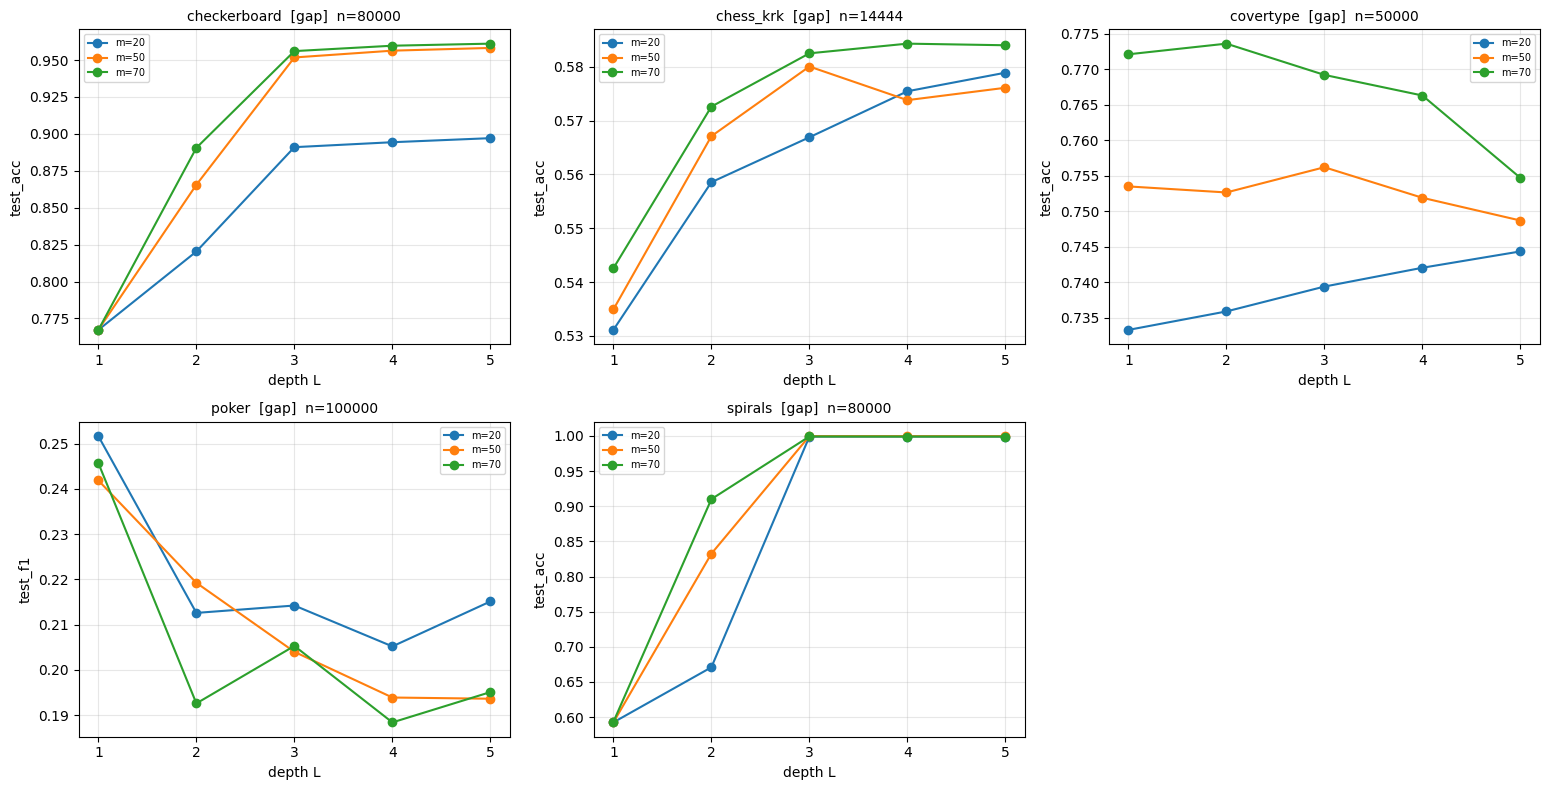

saved fig_exp3_depth_curves.png


In [102]:
def baseline_val(sub, metric):
    """RBF reference: exact if available else RFF; plus flat arc-cosine. Returns dict."""
    out = {}
    ex = sub[sub.method == "rbf_exact"]
    rf = sub[sub.method == "rbf_rff"]
    fl = sub[sub.method == "flat_arccos"]
    out["rbf"] = (ex[metric].mean(), "exact") if len(ex) else                  ((rf[metric].mean(), "rff") if len(rf) else (np.nan, "none"))
    out["flat"] = fl[metric].mean() if len(fl) else np.nan
    return out

datasets = sorted(df.dataset.unique())
ncol = 3; nrow = int(np.ceil(len(datasets)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 4*nrow)); axes = np.array(axes).ravel()
for i, ds in enumerate(datasets):
    ax = axes[i]; metric = meta[ds]["metric"]
    sub = df[(df.dataset == ds) & (df.n == meta[ds]["nmax"])]
    arch = sub[(sub.method == "arch") & (sub.m.isin(COMMON_M))]
    for m in sorted(arch.m.unique()):
        a = arch[arch.m == m].groupby("L")[metric].mean()
        ax.plot(a.index, a.values, marker="o", label=f"m={m}")
    base = baseline_val(sub, metric)
    ax.set_title(f"{ds}  [{meta[ds]['panel']}]  n={int(meta[ds]['nmax'])}", fontsize=10)
    ax.set_xlabel("depth L"); ax.set_ylabel(metric); ax.set_xticks(sorted(arch.L.unique()))
    ax.grid(alpha=.3); ax.legend(fontsize=7)
for j in range(len(datasets), len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.savefig("fig_exp3_depth_curves.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp3_depth_curves.png")

## 3. Overfitting check: train vs test with depth

Depth can raise *training* score without helping test (the poker failure mode). For each dataset
(largest n, best width) we plot train and test headline metric vs L. A widening train--test gap is
the overfitting signature; parallel curves mean depth generalises.

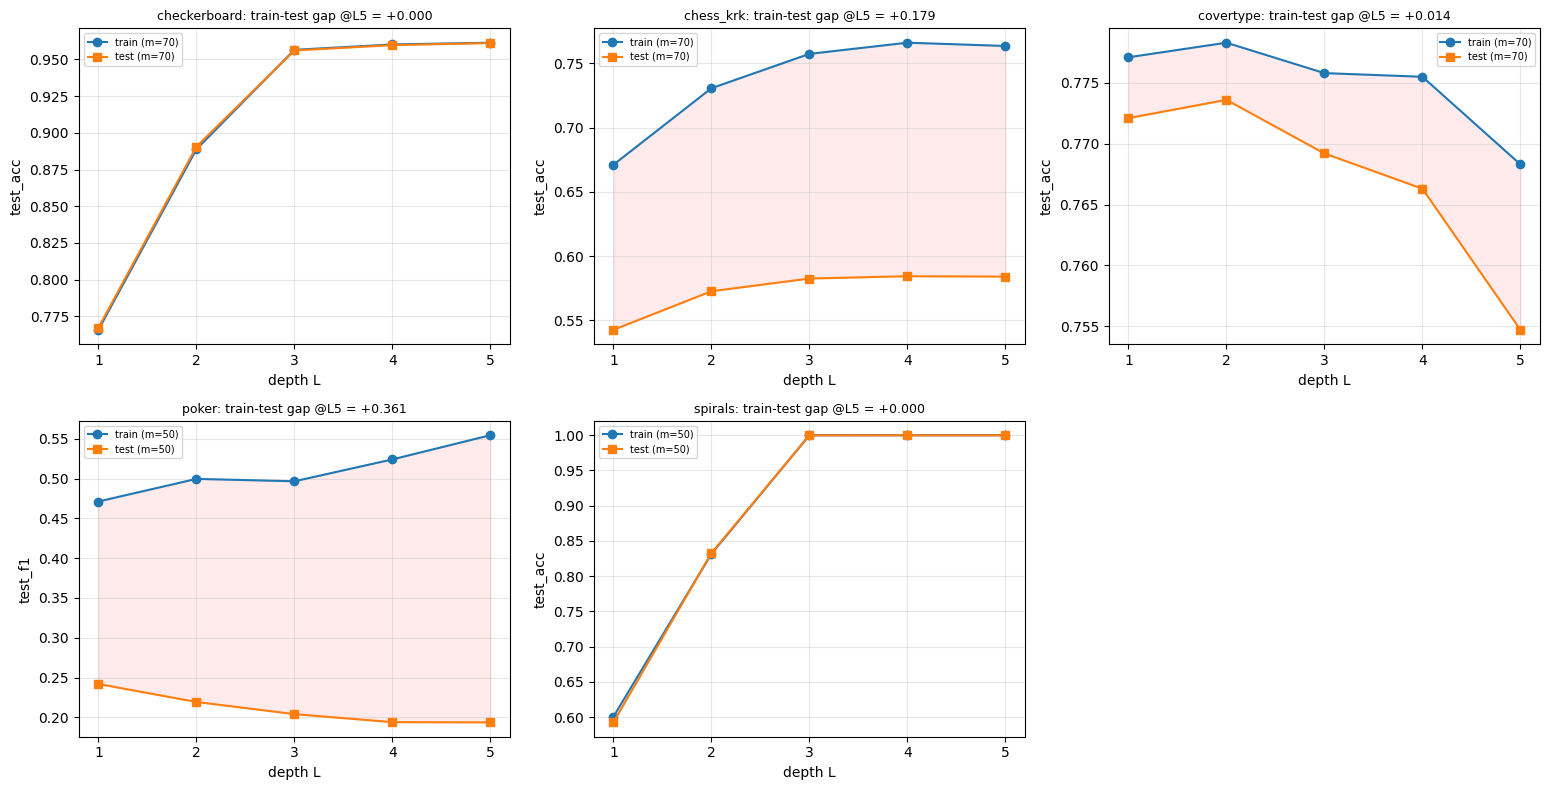

saved fig_exp3_overfit.png


In [103]:
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 4*nrow)); axes = np.array(axes).ravel()
tr_metric = {"test_acc":"train_acc","test_f1":"train_f1"}
for i, ds in enumerate(datasets):
    ax = axes[i]; metric = meta[ds]["metric"]; trm = tr_metric[metric]
    sub = df[(df.dataset == ds) & (df.n == meta[ds]["nmax"]) & (df.method == "arch") & (df.m.isin(COMMON_M))]
    if not len(sub): axes[i].axis("off"); continue
    # pick width with best test at max L
    best_m = (sub.groupby("m")[metric].max()).idxmax()
    s = sub[sub.m == best_m]
    tr = s.groupby("L")[trm].mean(); te = s.groupby("L")[metric].mean()
    ax.plot(tr.index, tr.values, marker="o", c="tab:blue", label=f"train (m={best_m})")
    ax.plot(te.index, te.values, marker="s", c="tab:orange", label=f"test (m={best_m})")
    ax.fill_between(tr.index, te.values, tr.values, color="red", alpha=.08)
    gap = (tr.values[-1]-te.values[-1])
    ax.set_title(f"{ds}: train-test gap @L{int(tr.index[-1])} = {gap:+.3f}", fontsize=9)
    ax.set_xlabel("depth L"); ax.set_ylabel(metric); ax.set_xticks(sorted(s.L.unique()))
    ax.grid(alpha=.3); ax.legend(fontsize=7)
for j in range(len(datasets), len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.savefig("fig_exp3_overfit.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp3_overfit.png")

## 4. The falsifiability plot: depth gain vs the MLP/RBF gap

The central test. For each dataset (largest n): **depth gain** = best-over-L minus L=1 (at the best
width), versus the **gap** = RBF reference minus flat arc-cosine (the headroom one block leaves).
The prediction is a positive association on the gap panel and ~0 gain on the controls. We mark panels
by colour so a control showing a large depth gain (which would falsify the account) is visible.

     dataset panel   metric     gap  depth_gain  best_m     l1   best rbf_kind
checkerboard   gap test_acc -0.0300      0.1299      20 0.7672 0.8971      rff
   chess_krk   gap test_acc  0.0638      0.0478      20 0.5311 0.5789    exact
   covertype   gap test_acc -0.0564      0.0111      20 0.7333 0.7444      rff
       poker   gap  test_f1  0.0507      0.0000      20 0.2517 0.2517      rff
     spirals   gap test_acc  0.1447      0.4066      20 0.5925 0.9991      rff


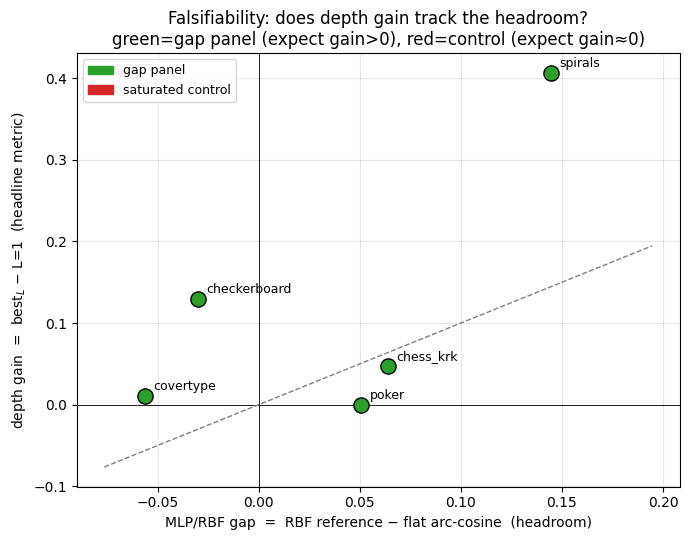

saved fig_exp3_falsifiability.png

Pearson r(gap, depth_gain) = 0.681  (positive supports the headroom account)


In [104]:
rows = []
for ds in datasets:
    metric = meta[ds]["metric"]; nmax = meta[ds]["nmax"]
    sub = df[(df.dataset == ds) & (df.n == nmax)]
    arch = sub[(sub.method == "arch") & (sub.m.isin(COMMON_M))]
    if not len(arch): continue
    # depth gain at the width that maximises best-L test
    per_m = arch.groupby(["m","L"])[metric].mean().reset_index()
    best_m = per_m.loc[per_m.groupby("m")[metric].max().reset_index()[metric].idxmax(),"m"]              if len(per_m) else None
    mm = per_m[per_m.m == best_m]
    l1 = mm[mm.L == mm.L.min()][metric].values[0]
    best = mm[metric].max()
    gain = best - l1
    base = baseline_val(sub, metric)
    gap = base["rbf"][0] - base["flat"] if not np.isnan(base["rbf"][0]) and not np.isnan(base["flat"]) else np.nan
    rows.append(dict(dataset=ds, panel=meta[ds]["panel"], metric=metric,
                     gap=gap, depth_gain=gain, best_m=int(best_m),
                     l1=l1, best=best, rbf_kind=base["rbf"][1]))
gain_df = pd.DataFrame(rows)
print(gain_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7,5.5))
colors = {"gap":"tab:green","control":"tab:red"}
for _, r in gain_df.iterrows():
    ax.scatter(r.gap, r.depth_gain, s=120, c=colors.get(r.panel,"gray"),
               edgecolors="k", zorder=3)
    ax.annotate(r.dataset, (r.gap, r.depth_gain), fontsize=9,
                xytext=(6,4), textcoords="offset points")
ax.axhline(0, c="k", lw=.6); ax.axvline(0, c="k", lw=.6)
lims = [min(gain_df.gap.min(),0)-0.02, gain_df.gap.max()+0.05]
ax.plot(lims, lims, ls="--", c="gray", lw=1, label="gain = gap (full recovery)")
ax.set_xlabel("MLP/RBF gap  =  RBF reference − flat arc-cosine  (headroom)")
ax.set_ylabel("depth gain  =  best$_L$ − L=1  (headline metric)")
ax.set_title("Falsifiability: does depth gain track the headroom?\n"
             "green=gap panel (expect gain>0), red=control (expect gain≈0)")
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color="tab:green",label="gap panel"),
                   mp.Patch(color="tab:red",label="saturated control")],
          loc="upper left", fontsize=9)
ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("fig_exp3_falsifiability.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp3_falsifiability.png")
if len(gain_df) > 2:
    r = np.corrcoef(gain_df.gap.fillna(0), gain_df.depth_gain)[0,1]
    print(f"\nPearson r(gap, depth_gain) = {r:.3f}  (positive supports the headroom account)")

## 5. Width as a regulariser: effect of m by sample size

Hypothesis: m helps more at small n (variance control) and saturates as n grows. For each dataset,
headline metric vs m (at the best L), one line per n. A downward-sloping benefit of m as n increases
supports the regulariser reading.

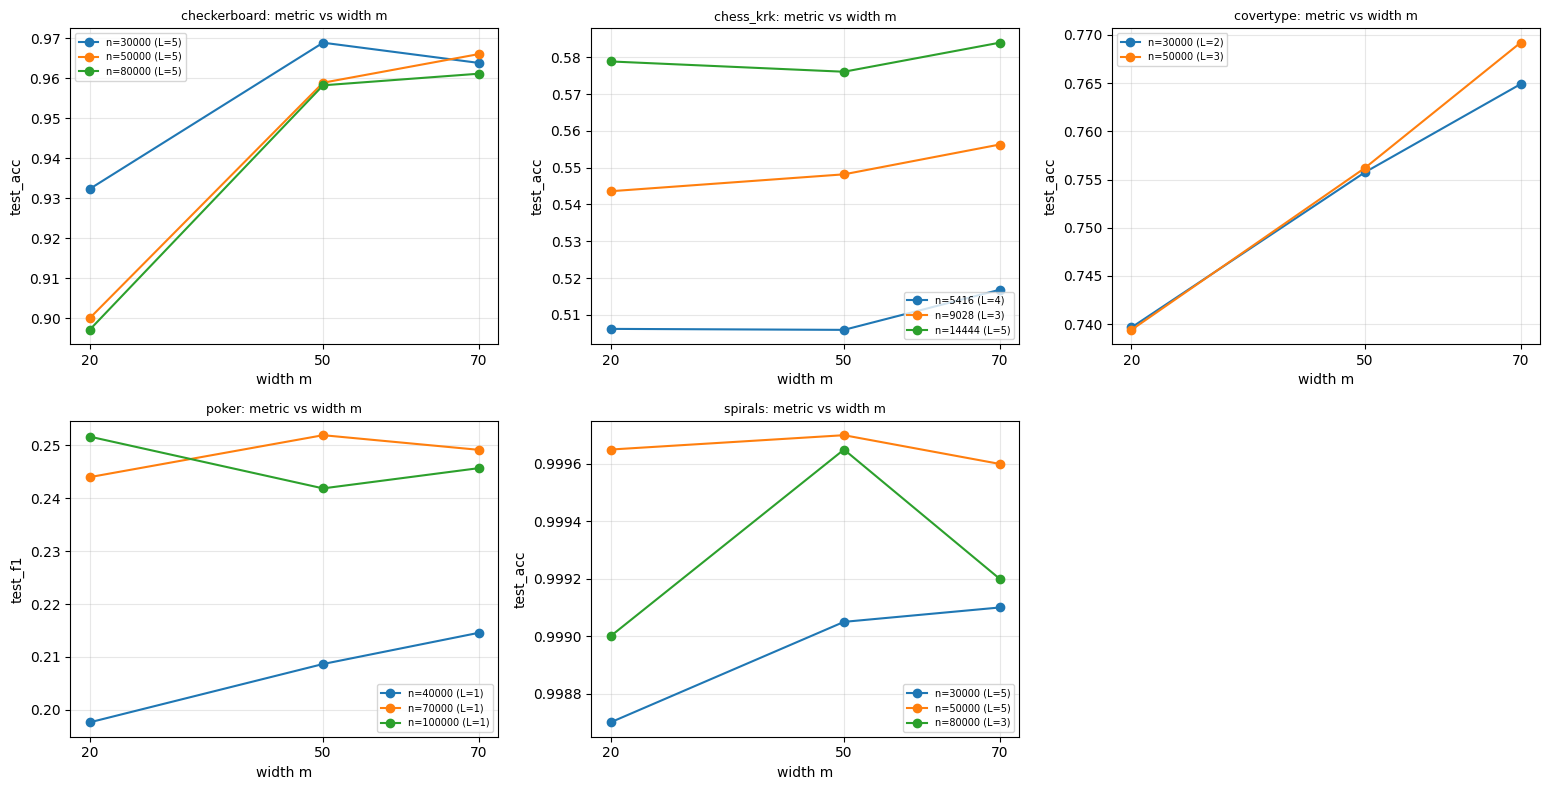

saved fig_exp3_width.png


In [105]:
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 4*nrow)); axes = np.array(axes).ravel()
for i, ds in enumerate(datasets):
    ax = axes[i]; metric = meta[ds]["metric"]
    sub = df[(df.dataset == ds) & (df.method == "arch") & (df.m.isin(COMMON_M))]
    if not len(sub): axes[i].axis("off"); continue
    for n in sorted(sub.n.unique()):
        s = sub[sub.n == n]
        bestL = s.groupby("L")[metric].mean().idxmax()
        a = s[s.L == bestL].groupby("m")[metric].mean()
        ax.plot(a.index, a.values, marker="o", label=f"n={int(n)} (L={int(bestL)})")
    ax.set_title(f"{ds}: metric vs width m", fontsize=9)
    ax.set_xlabel("width m"); ax.set_ylabel(metric); ax.set_xticks(COMMON_M)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
for j in range(len(datasets), len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.savefig("fig_exp3_width.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp3_width.png")

## 6. Compute time — scaling with n, L, and the RBF feasibility wall

The timing story: how arch time grows with n and L, and where exact RBF becomes intractable
(the reason the architecture exists). Left: mean arch fit-time vs n by L. Right: arch vs exact-RBF
vs RFF-RBF time per dataset, showing the feasibility boundary.

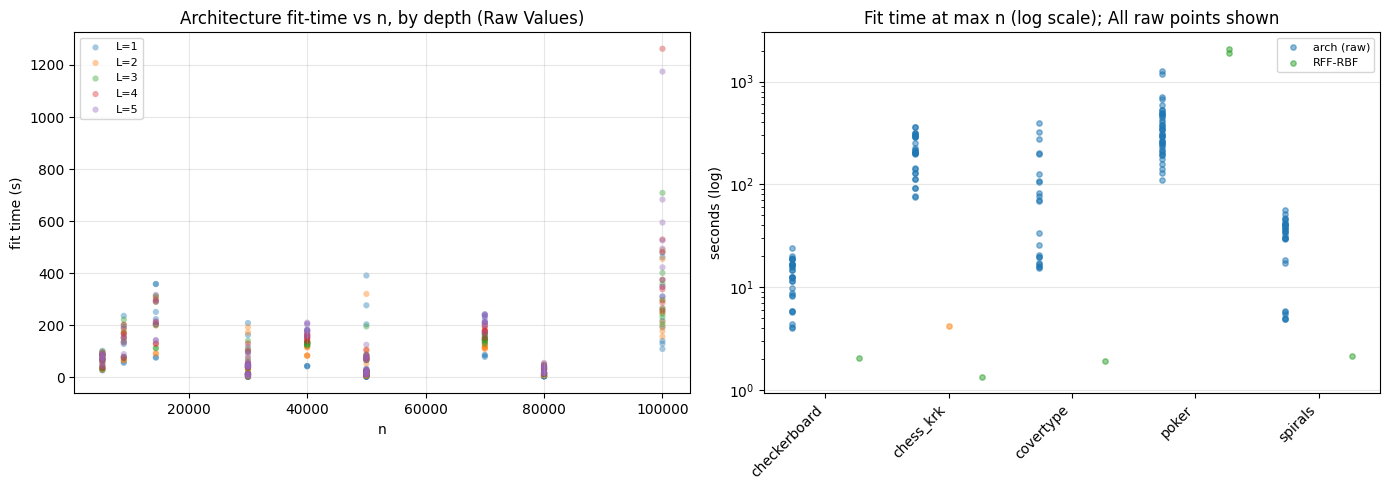

saved fig_exp3_timing_raw.png


In [106]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------------------
# LEFT: Real arch time vs n, by L (Showing EVERY raw data point)
# -------------------------------------------------------------------------
a = df[(df.method=="arch") & (df.m.isin(COMMON_M))]
for L in sorted(a.L.unique()):
    a_L = a[a.L==L]
    # Usamos scatter para pintar cada tiempo de ejecución real individual
    ax[0].scatter(a_L["n"], a_L["fit_time_s"], alpha=0.4, s=20, label=f"L={L}", edgecolors='none')

ax[0].set_title("Architecture fit-time vs n, by depth (Raw Values)")
ax[0].set_xlabel("n")
ax[0].set_ylabel("fit time (s)")
ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8)

# -------------------------------------------------------------------------
# RIGHT: Per-dataset time comparison at max n (Stripplot / Raw points)
# -------------------------------------------------------------------------
labels = []
w = 0.27  # Desplazamiento para separar los métodos en el eje X

for i, ds in enumerate(datasets):
    nmax = meta[ds]["nmax"]
    sub = df[(df.dataset==ds) & (df.n==nmax)]
    labels.append(ds)
    
    # Extraemos las series con todos los valores reales (sin .mean())
    arch_vals = sub[(sub.method=="arch") & (sub.m.isin(COMMON_M))].fit_time_s
    ex_vals = sub[sub.method=="rbf_exact"].fit_time_s
    rff_vals = sub[sub.method=="rbf_rff"].fit_time_s
    
    # Pintamos los puntos reales desplazados horizontalmente según su método
    ax[1].scatter(np.full_like(arch_vals, i - w), arch_vals, color='C0', alpha=0.5, s=15, 
                  label="arch (raw)" if i == 0 else "")
    
    if len(ex_vals):
        ax[1].scatter(np.full_like(ex_vals, i), ex_vals, color='C1', alpha=0.5, s=15, 
                      label="exact RBF" if i == 0 else "")
        
    ax[1].scatter(np.full_like(rff_vals, i + w), rff_vals, color='C2', alpha=0.5, s=15, 
                  label="RFF-RBF" if i == 0 else "")

x = np.arange(len(labels))
ax[1].set_yscale("log")
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels, rotation=45, ha="right")
ax[1].set_title("Fit time at max n (log scale); All raw points shown")
ax[1].set_ylabel("seconds (log)")
ax[1].grid(alpha=.3, axis="y")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_exp3_timing_raw.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved fig_exp3_timing_raw.png")

## 7. Summary table for the thesis

One row per dataset: panel, headline metric, flat arc-cosine, RBF reference, best architecture
(metric, m, L), depth gain, and the gap. This is the table the Results section is built from.

In [107]:
summary = []
for ds in datasets:
    metric = meta[ds]["metric"]; nmax = meta[ds]["nmax"]
    sub = df[(df.dataset==ds)&(df.n==nmax)]
    base = baseline_val(sub, metric)
    arch = sub[(sub.method=="arch")&(sub.m.isin(COMMON_M))]
    g = gain_df[gain_df.dataset==ds]
    per = arch.groupby(["m","L"])[metric].mean().reset_index()
    brow = per.loc[per[metric].idxmax()] if len(per) else None
    summary.append(dict(
        dataset=ds, panel=meta[ds]["panel"], n=int(nmax), metric=metric,
        flat=round(base["flat"],4),
        rbf=round(base["rbf"][0],4) if not np.isnan(base["rbf"][0]) else None,
        rbf_kind=base["rbf"][1],
        best=round(brow[metric],4) if brow is not None else None,
        best_m=int(brow.m) if brow is not None else None,
        best_L=int(brow.L) if brow is not None else None,
        depth_gain=round(g.depth_gain.values[0],4) if len(g) else None,
        gap=round(g.gap.values[0],4) if len(g) and not np.isnan(g.gap.values[0]) else None,
    ))
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv("exp3_summary_table.csv", index=False)
print("\nsaved exp3_summary_table.csv")

     dataset panel      n   metric   flat    rbf rbf_kind   best  best_m  best_L  depth_gain     gap
checkerboard   gap  80000 test_acc 0.7659 0.7359      rff 0.9611      70       5      0.1299 -0.0300
   chess_krk   gap  14444 test_acc 0.5336 0.5974    exact 0.5843      70       4      0.0478  0.0638
   covertype   gap  50000 test_acc 0.7852 0.7288      rff 0.7736      70       2      0.0111 -0.0564
       poker   gap 100000  test_f1 0.1908 0.2416      rff 0.2517      20       1      0.0000  0.0507
     spirals   gap  80000 test_acc 0.5898 0.7345      rff 0.9996      50       3      0.4066  0.1447

saved exp3_summary_table.csv


## How to read these results

The headroom account predicts a specific pattern, and §4 is where it stands or falls: depth gain
should be positive on the green gap-panel points and clustered near zero on the red controls. A
control with a large positive depth gain would count against the account; a gap dataset with no gain
(like poker, if depth overfits rather than recovers) is a case where the headroom is real but this
architecture cannot exploit it — a limitation to report honestly, not hide.

Cross-reference §2 (does depth climb toward the RBF/flat references?) with §3 (is the climb in test or
only in train?). A dataset where depth raises test toward the ceiling is a clean success; one where
only train rises is overfitting. §5 addresses whether width regularises, and §6 documents the compute
cost and the exact-RBF feasibility wall that motivates the whole architecture.